# The cached detection result set

Every detection number this project reports is a slice of one file. This notebook
opens that file, says exactly what a row in it is, and then asks the 3 questions
that decide whether any table built on it can be trusted: what is covered, what is
missing, and how much of the reported performance depends on a choice a deployed
defender could not make.

It is CPU only. It reads `results/detection_summary.csv` and the 794
`results/*/psbd_metrics.json` records that file was collapsed from. No checkpoint is
loaded and no forward pass is run.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)

SUMMARY = "results/detection_summary.csv"
frame = pd.read_csv(SUMMARY)
print(f"{SUMMARY}: {frame.shape[0]} rows, {frame.shape[1]} columns")

results/detection_summary.csv: 30378 rows, 26 columns


## What one row is

A row is one **cell** of the detection experiment, which is 5 coordinates:

| coordinate | column | what it fixes |
|---|---|---|
| checkpoint | `folder` | architecture, dataset, attack, poison rate, optimizer |
| position | `position` | where in the network the perturbation is injected |
| operator | `operator` | what the perturbation does to the tensor it lands on |
| rate | `rate` | how strong the perturbation is |
| rate rule | `rule` | how that rate was chosen |

`placement` is the concatenation of position and operator, and it is the name the
cache directory carries on disk. The bare name is the paper's dropout, which is why
`scripts/detection_summary.py` splits an operator suffix off the end and falls back
to `dropout` when there is none.

The 4th coordinate is the one worth pausing on. A dropout rate of 0.4 is not the
same intervention at 2 different positions, so `rule` exists to say which principle
picked the rate. `adaptive` is the paper's own rule and reads clean validation data
only. `oracle` picks the rate with the best AUROC after the fact. `matched_sigma*`
picks the rate whose clean validation shift ratio sits nearest a target, which is
the only rule under which 2 positions are being asked the same question.

In [2]:
one_cell = frame[
    (frame["folder"] == "vit_cifar100_badnet_a2o_0_01")
    & (frame["placement"] == "before_attention_norm_token_mask")
]
one_cell[
    [
        "rule",
        "rate",
        "achieved_shift_ratio",
        "auroc",
        "tpr",
        "fpr",
        "threshold",
        "quantile",
    ]
].round(4)

,rule,rate,achieved_shift_ratio,auroc,tpr,fpr,threshold,quantile
5266,adaptive,0.5,NaN,0.9788,0.9987,0.2419,0.8202,0.25
5267,oracle,0.5,NaN,0.9788,0.9987,0.2419,0.8202,0.25
5268,matched_sigma0.2,0.1,0.1305,0.6530,0.0555,0.2587,0.0000,0.25
5269,matched_sigma0.4,0.3,0.4698,0.8977,0.9627,0.2402,0.1540,0.25
5270,matched_sigma0.6,0.4,0.6925,0.9581,0.9968,0.2558,0.6041,0.25
5271,matched_sigma0.8,0.5,0.8595,0.9788,0.9987,0.2419,0.8202,0.25


## AUROC against TPR and FPR

The 3 numbers answer different questions and only 1 of them is threshold free.

**AUROC** ranks. It asks whether a backdoored input's prediction-shift uncertainty
tends to sit below a clean one's, over every possible threshold at once. Below 0.5
is not a weak detector, it is an **inverted** one: the statistic runs the wrong way
and flagging the low tail flags clean samples preferentially.

**TPR and FPR** are one point on that curve, produced by an actual threshold. In
this file that threshold is always the 25th percentile of clean validation PSU,
which is the paper's rule and is deployable, because clean validation data is
something a defender has. The consequence is that FPR is nearly uninformative here
by construction: it is measured on clean test PSU drawn from the same distribution
the quantile was taken from, so it lands near 0.25 whatever the placement does.

In [3]:
by_rule = frame.groupby("rule").agg(
    rows=("auroc", "size"),
    mean_auroc=("auroc", "mean"),
    mean_tpr=("tpr", "mean"),
    mean_fpr=("fpr", "mean"),
    mean_rate=("rate", "mean"),
)
print(
    f"quantile column takes {frame['quantile'].nunique()} distinct value(s): "
    f"{sorted(frame['quantile'].unique())}"
)
by_rule.round(4)

quantile column takes 1 distinct value(s): [np.float64(0.25)]


,rows,mean_auroc,mean_tpr,mean_fpr,mean_rate
rule,,,,,
adaptive,4843,0.7667,0.6424,0.2431,0.7264
matched_sigma0.2,5107,0.6449,0.4974,0.2537,0.3272
matched_sigma0.4,5107,0.6925,0.5640,0.2515,0.4470
matched_sigma0.6,5107,0.7405,0.6282,0.2476,0.5637
matched_sigma0.8,5107,0.7673,0.6562,0.2440,0.7250
oracle,5107,0.8192,0.7336,0.2432,0.9009


Every rule sits at an FPR of about 0.25, the quantile itself. That is the direct
evidence that **the threshold in this file is the deployable one in every row**,
including the `oracle` rows. The oracle here is an oracle over the *rate*, not over
the *threshold*.

That distinction matters because audit finding A5 (`docs/audit-2026-09-07.md`) is
about a different leak: `defence_tables.py` once placed its threshold on the ROC
curve of the very clean and poisoned split being detected, and labelled the result
plainly as `TPR@1%`. That threshold oracle is not present in this file. The rate
oracle measured below is a smaller leak, and it is still a leak, because picking the
best rate in hindsight reads the poison labels the detector exists to predict.

## Coverage

The reporting bar in `docs/hypothesis/README.md` demands 3 axes at once: 4 datasets,
3 poison rates, and the 5 attack panel. What follows is what the file actually
holds against that bar.

In [4]:
print("checkpoints   ", frame["folder"].nunique())
for column in [
    "architecture",
    "dataset",
    "attack",
    "poison_rate",
    "optimizer",
    "label_mode",
    "position",
    "operator",
    "placement",
    "rule",
]:
    values = frame[column].dropna().unique()
    shown = ", ".join(sorted(map(str, values))[:8])
    more = "" if len(values) <= 8 else f", ... (+{len(values) - 8})"
    print(f"{column:14} {len(values):>3}  {shown}{more}")

checkpoints    283
architecture     2  swin, vit
dataset          4  cifar10, cifar100, gtsrb, tiny
attack          11  adaptive_blend, badnet_a2a, badnet_a2o, benign, blend, bpp, lc, lf, ... (+3)
poison_rate      5  0.0, 0.005, 0.01, 0.05, 0.1
optimizer        1  adam
label_mode       3  all_to_all, all_to_one, clean_label
position        18  after_attention_residual, after_embedding, after_mlp_residual, attention_heads, attention_norm_out, before_attention, before_attention_norm, before_attention_residual, ... (+10)
operator         8  channel_mask, dropout, droppath, gain_scale, gaussian, head_mask, scale_up, token_mask
placement       80  after_attention_residual, after_attention_residual_channel_mask, after_attention_residual_gaussian, after_attention_residual_gaussian_batchstd, after_attention_residual_token_mask, after_embedding, after_embedding_channel_mask, after_embedding_gaussian, ... (+72)
rule             6  adaptive, matched_sigma0.2, matched_sigma0.4, matched_sigma0.6, m

In [5]:
# The summary is built from the stage-2 records, so any gap between the two is a
# gap in what the CSV can be asked, not in what was measured.
records = sorted(glob.glob("results/*/psbd_metrics.json"))
on_disk = {os.path.basename(os.path.dirname(path)) for path in records}
in_csv = set(frame["folder"])
absent = on_disk - in_csv

print(f"psbd_metrics.json records on disk : {len(on_disk)}")
print(f"checkpoints present in the CSV    : {len(in_csv)}")
print(f"absent from the CSV               : {len(absent)}")
print(f"  of which SAM-trained            : {sum('sam_rho' in f for f in absent)}")
print(f"  absent for any other reason     : {sum('sam_rho' not in f for f in absent)}")

psbd_metrics.json records on disk : 795
checkpoints present in the CSV    : 283
absent from the CSV               : 512
  of which SAM-trained            : 512
  absent for any other reason     : 0


Every absent checkpoint is a SAM run, which `scripts/detection_summary.py` drops by
default and behind a documented argument. That exclusion is deliberate and recorded
in section 4.7 of the results report. Nothing else is silently missing at the
checkpoint level.

The placement level is a different story.

In [6]:
# A placement is only reportable if stage 2 wrote it into psbd_metrics.json. The raw
# per-pass cache under results/<folder>/psbd/ is what stage 2 reads, so comparing the
# two says whether the summary reflects everything that was measured.
stage2_gap = []
for path in records:
    folder = os.path.basename(os.path.dirname(path))
    with open(path) as handle:
        analysed = set((json.load(handle).get("placements") or {}))
    cache_dir = os.path.join("results", folder, "psbd")
    cached = (
        {
            name
            for name in os.listdir(cache_dir)
            if os.path.isdir(os.path.join(cache_dir, name))
        }
        if os.path.isdir(cache_dir)
        else set()
    )
    stage2_gap.append(
        {
            "folder": folder,
            "analysed": len(analysed),
            "cached": len(cached),
            "unanalysed": len(cached - analysed),
        }
    )

stage2_gap = pd.DataFrame(stage2_gap)
behind = stage2_gap[stage2_gap["unanalysed"] > 0]
print(f"checkpoints whose cache holds placements stage 2 never analysed: {len(behind)}")
print(f"total unanalysed placement directories: {int(behind['unanalysed'].sum())}")
behind.sort_values("unanalysed", ascending=False).head(10)

checkpoints whose cache holds placements stage 2 never analysed: 159
total unanalysed placement directories: 1574


,folder,analysed,cached,unanalysed
519,vit_cifar10_lf_0_05,14,56,42
514,vit_cifar10_lf_0_01,14,54,40
438,vit_cifar10_badnet_a2a_0_01_sam_rho_0_1,4,35,31
443,vit_cifar10_badnet_a2a_0_05_sam_rho_0_1,4,35,31
448,vit_cifar10_badnet_a2a_0_1_sam_rho_0_1,4,35,31
454,vit_cifar10_badnet_a2o_0_01_sam_rho_0_1,4,35,31
450,vit_cifar10_badnet_a2a_0_1_sam_rho_0_2,4,31,27
439,vit_cifar10_badnet_a2a_0_01_sam_rho_0_15,4,31,27
440,vit_cifar10_badnet_a2a_0_01_sam_rho_0_2,4,31,27
455,vit_cifar10_badnet_a2o_0_01_sam_rho_0_15,4,31,27


This is a real limit on every table built from the summary, and it is worth stating
plainly rather than as a footnote. The measurement exists on disk. It is simply not
in the record the tables read.

The clearest case is CIFAR-10, where the whole operator grid was swept and none of
it reached stage 2.

In [7]:
example = "vit_cifar10_badnet_a2o_0_01"
with open(f"results/{example}/psbd_metrics.json") as handle:
    analysed = set(json.load(handle)["placements"])
cached = {
    name
    for name in os.listdir(f"results/{example}/psbd")
    if os.path.isdir(f"results/{example}/psbd/{name}")
}
print(f"{example}")
print(f"  analysed into psbd_metrics.json : {len(analysed)}")
print(f"  present in the raw cache        : {len(cached)}")
print(f"  measured but never analysed     : {len(cached - analysed)}")
print()
print(
    "missing operator placements:",
    sorted(
        name
        for name in cached - analysed
        if name.endswith(("token_mask", "gain_scale", "channel_mask", "droppath"))
    )[:8],
)

vit_cifar10_badnet_a2o_0_01
  analysed into psbd_metrics.json : 50
  present in the raw cache        : 61
  measured but never analysed     : 11

missing operator placements: []


## The coverage grid

Which `(architecture, dataset, attack, poison rate)` cells exist at all, counted by
how many distinct placements were measured on them. A zero is a hole.

In [8]:
PANEL = ["badnet_a2o", "blend", "wanet", "lc", "adaptive_blend"]
POISON_RATES = [0.01, 0.05, 0.1]

grid = (
    frame[frame["attack"].isin(PANEL) & frame["poison_rate"].isin(POISON_RATES)]
    .groupby(["architecture", "dataset", "poison_rate", "attack"])["placement"]
    .nunique()
    .unstack("attack")
    .reindex(columns=PANEL)
)
full = pd.MultiIndex.from_product(
    [
        sorted(frame["architecture"].unique()),
        sorted(frame["dataset"].unique()),
        POISON_RATES,
    ],
    names=["architecture", "dataset", "poison_rate"],
)
grid = grid.reindex(full).fillna(0).astype(int)
print(f"panel cells demanded by the reporting bar : {grid.size}")
print(f"cells with at least 1 placement measured  : {int((grid > 0).sum().sum())}")
print(f"cells entirely missing                    : {int((grid == 0).sum().sum())}")
grid

panel cells demanded by the reporting bar : 120
cells with at least 1 placement measured  : 99
cells entirely missing                    : 21


attack                             badnet_a2o  blend  wanet  lc  adaptive_blend
architecture dataset  poison_rate                                              
swin         cifar10  0.01                  3     10      0   0               0
                      0.05                  7      3     10   0              10
                      0.10                  7      3      3   1              10
             cifar100 0.01                 12     12      7  12               7
                      0.05                 12     12     12  12              12
                      0.10                 12     12     12   7              12
             gtsrb    0.01                  0      0      0   0               0
                      0.05                  0      0      0   0               0
                      0.10                  0      0      0   0               0
             tiny     0.01                  4      4      4   4               4
                      0.05                  4      4      4   4               4
                      0.10                  4      4      4   4               4
vit          cifar10  0.01                 49     51      7   7              41
                      0.05                 50     51     45   2              43
                      0.10                 59     58     53  51              52
             cifar100 0.01                 47     47      4  44              38
                      0.05                 44     44     38  38              44
                      0.10                 42     42     42  36              42
             gtsrb    0.01                 53     53      0   0               2
                      0.05                 53     53     45   2              53
                      0.10                 51     51     51   2              51
             tiny     0.01                 56     56      4   4               6
                      0.05                 53     53     53  45              53
                      0.10                 51     51     51  43              51

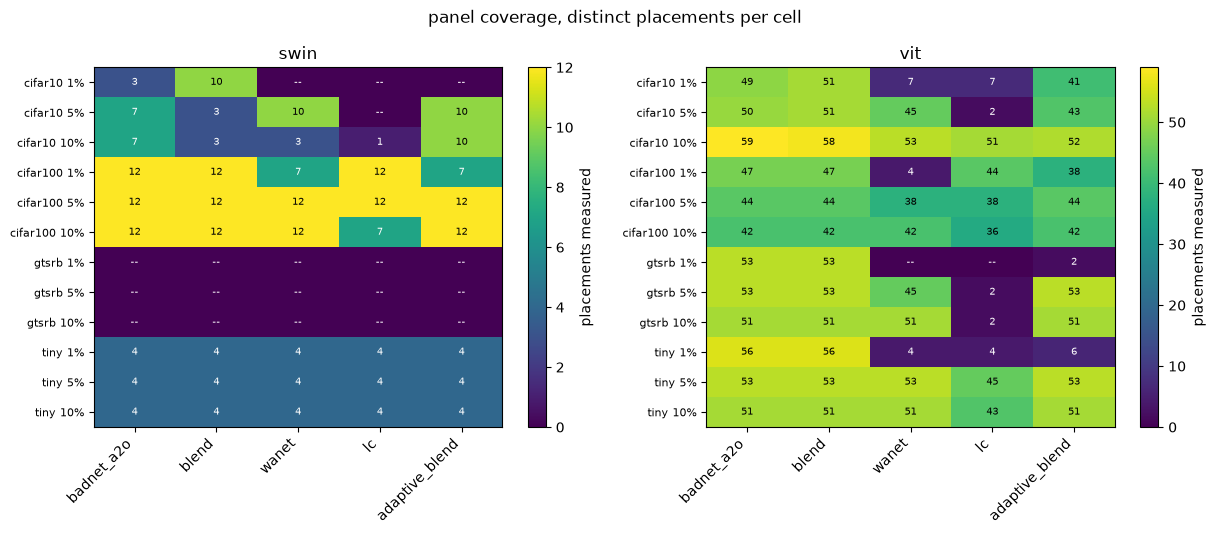

In [9]:
def plot_coverage(grid):
    """Placements measured per panel cell, one panel per architecture."""
    architectures = sorted({index[0] for index in grid.index})
    figure, axes = plt.subplots(
        1, len(architectures), figsize=(6.2 * len(architectures), 5.4)
    )
    axes = np.atleast_1d(axes)
    for axis, architecture in zip(axes, architectures):
        block = grid.loc[architecture]
        image = axis.imshow(block.to_numpy(), cmap="viridis", vmin=0, aspect="auto")
        axis.set_xticks(range(block.shape[1]))
        axis.set_xticklabels(block.columns, rotation=45, ha="right")
        axis.set_yticks(range(block.shape[0]))
        axis.set_yticklabels(
            [f"{d} {int(r * 100)}%" for d, r in block.index], fontsize=8
        )
        axis.set_title(architecture)
        for row in range(block.shape[0]):
            for column in range(block.shape[1]):
                count = block.iat[row, column]
                axis.text(
                    column,
                    row,
                    count if count else "--",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if count < block.to_numpy().max() * 0.6 else "black",
                )
        figure.colorbar(image, ax=axis, label="placements measured")
    figure.suptitle("panel coverage, distinct placements per cell")
    figure.tight_layout()
    return figure


plot_coverage(grid)
plt.show()

Three separate things produce a zero or a small number in that grid, and only one of
them is a hole in the experiment.

**No checkpoint exists.** Swin on GTSRB is absent entirely, all 15 panel cells. The
Swin operator grid was only ever run on CIFAR-100, which is why the Swin CIFAR-10 and
Tiny rows carry 3 to 10 placements against CIFAR-100's 12.

**The attack did not implant.** A cell can carry a full placement sweep and still be
unusable. `wanet` at 1% has checkpoints on CIFAR-10, CIFAR-100 and Tiny, and its
peak ASR at that rate is 0.123, 0.064 and 0.525. There is no backdoor to detect, so
those cells are reported as attack failures rather than as detection failures.

**Stage 2 never analysed what was measured.** That is the ViT CIFAR-10 row, where 14
placements reached the record out of the 49 that sit in the cache.

In [10]:
implanted = frame[frame["attack"].isin(PANEL) & frame["poison_rate"].isin(POISON_RATES)]
asr_grid = (
    implanted.groupby(["dataset", "poison_rate", "attack"])["asr"]
    .max()
    .unstack("attack")
    .reindex(columns=PANEL)
)
print("peak ASR per panel cell, ViT and Swin pooled. Blank means no checkpoint exists.")
asr_grid.round(3)

peak ASR per panel cell, ViT and Swin pooled. Blank means no checkpoint exists.


attack                badnet_a2o  blend  wanet     lc  adaptive_blend
dataset  poison_rate                                                 
cifar10  0.01                1.0  1.000  0.123  0.249           0.640
         0.05                1.0  1.000  0.978  0.408           0.865
         0.10                1.0  1.000  0.977  0.979           0.992
cifar100 0.01                1.0  0.999  0.064  0.996           0.800
         0.05                1.0  1.000  0.865  0.850           0.948
         0.10                1.0  1.000  0.930  0.788           0.972
gtsrb    0.01                1.0  1.000    NaN    NaN           0.448
         0.05                1.0  1.000  0.777  0.239           0.986
         0.10                1.0  1.000  0.922  0.129           1.000
tiny     0.01                1.0  1.000  0.525  0.690           0.768
         0.05                1.0  1.000  0.965  0.706           0.924
         0.10                1.0  1.000  0.980  0.723           0.965

In [11]:
capped = frame[frame["poison_rate_capped"] == True]
print(
    f"rows whose requested poison rate was capped by clean-label eligibility: {len(capped)}"
)
if len(capped):
    print(
        capped.groupby(["dataset", "attack"])[["poison_rate", "realized_poison_rate"]]
        .agg(["min", "max"])
        .round(4)
    )

rows whose requested poison rate was capped by clean-label eligibility: 1562
                poison_rate      realized_poison_rate        
                        min  max                  min     max
dataset  attack                                              
cifar100 lc            0.05  0.1               0.0100  0.0100
         sig           0.05  0.1               0.0100  0.0100
gtsrb    lc            0.05  0.1               0.0056  0.0056
tiny     lc            0.01  0.1               0.0050  0.0050
         sig           0.01  0.1               0.0050  0.0050


Audit finding A8 in one table. Where `realized_poison_rate` is far below
`poison_rate`, any trend read along the poison rate axis for that attack is not a
poison rate trend.

## The distribution of AUROC

The one-sided convention is load bearing here. Nothing is flipped, so the left tail
of this distribution is real failure and not a sign convention.

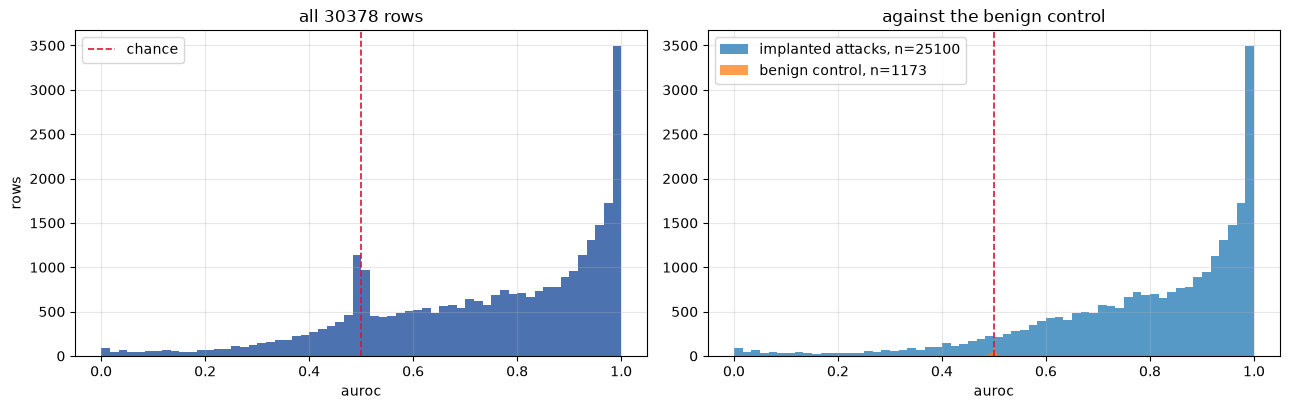

implanted attacks, mean auroc : 0.7917  (n=25100)
benign control, mean auroc    : 0.4976  (n=1173)


In [12]:
def plot_auroc_distribution(frame):
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].hist(frame["auroc"], bins=60, color="#4C72B0")
    axes[0].axvline(0.5, ls="--", lw=1.2, c="crimson", label="chance")
    axes[0].set_xlabel("auroc")
    axes[0].set_ylabel("rows")
    axes[0].set_title(f"all {len(frame)} rows")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    scored = frame[
        (frame["asr"] >= 0.5) & (~frame["attack"].isin(["benign", "badnet_a2a"]))
    ]
    control = frame[frame["attack"] == "benign"]
    axes[1].hist(
        scored["auroc"],
        bins=60,
        alpha=0.75,
        label=f"implanted attacks, n={len(scored)}",
    )
    axes[1].hist(
        control["auroc"], bins=60, alpha=0.75, label=f"benign control, n={len(control)}"
    )
    axes[1].axvline(0.5, ls="--", lw=1.2, c="crimson")
    axes[1].set_xlabel("auroc")
    axes[1].set_title("against the benign control")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    figure.tight_layout()
    return figure


plot_auroc_distribution(frame)
plt.show()

scored = frame[
    (frame["asr"] >= 0.5) & (~frame["attack"].isin(["benign", "badnet_a2a"]))
]
print(
    f"implanted attacks, mean auroc : {scored['auroc'].mean():.4f}  (n={len(scored)})"
)
print(
    f"benign control, mean auroc    : {frame.loc[frame['attack'] == 'benign', 'auroc'].mean():.4f}"
    f"  (n={int((frame['attack'] == 'benign').sum())})"
)

The benign control is the sanity check the whole file rests on. It sits at chance,
so the separation measured elsewhere is not the detector reacting to the fact that a
triggered image is a different image.

In [13]:
def breakdown(column, minimum=0):
    table = frame.groupby(column).agg(
        rows=("auroc", "size"),
        mean=("auroc", "mean"),
        median=("auroc", "median"),
        p10=("auroc", lambda values: values.quantile(0.10)),
        worst=("auroc", "min"),
        inversions=("auroc", lambda values: int((values < 0.5).sum())),
    )
    table["inversion_rate"] = table["inversions"] / table["rows"]
    return table[table["rows"] >= minimum].sort_values("mean", ascending=False).round(3)


print("by architecture")
print(breakdown("architecture"))
print()
print("by dataset")
print(breakdown("dataset"))
print()
print("by poison rate")
print(breakdown("poison_rate"))

by architecture
               rows   mean  median    p10  worst  inversions  inversion_rate
architecture                                                                
vit           26550  0.739   0.784  0.448    0.0        4475           0.169
swin           3828  0.731   0.821  0.369    0.0         762           0.199

by dataset
          rows   mean  median    p10  worst  inversions  inversion_rate
dataset                                                                
gtsrb     5766  0.816   0.931  0.486  0.010         772           0.134
cifar10   8230  0.734   0.804  0.416  0.028        1686           0.205
tiny      7737  0.723   0.756  0.473  0.000        1155           0.149
cifar100  8645  0.704   0.732  0.426  0.000        1624           0.188

by poison rate
              rows   mean  median    p10  worst  inversions  inversion_rate
poison_rate                                                                
0.100        10912  0.758   0.826  0.427  0.000        1710     

In [14]:
print("by attack")
breakdown("attack")

by attack


,rows,mean,median,p10,worst,inversions,inversion_rate
attack,,,,,,,
bpp,4253,0.877,0.939,0.687,0.001,124,0.029
blend,4394,0.856,0.930,0.612,0.000,263,0.060
lf,3727,0.817,0.868,0.614,0.006,150,0.040
adaptive_blend,3415,0.814,0.853,0.590,0.008,178,0.052
badnet_a2o,4309,0.741,0.782,0.450,0.000,556,0.129
wanet,2853,0.675,0.704,0.372,0.008,650,0.228
sig,925,0.654,0.643,0.418,0.188,213,0.230
lc,2104,0.619,0.620,0.412,0.071,474,0.225
benign,1173,0.498,0.499,0.486,0.465,689,0.587


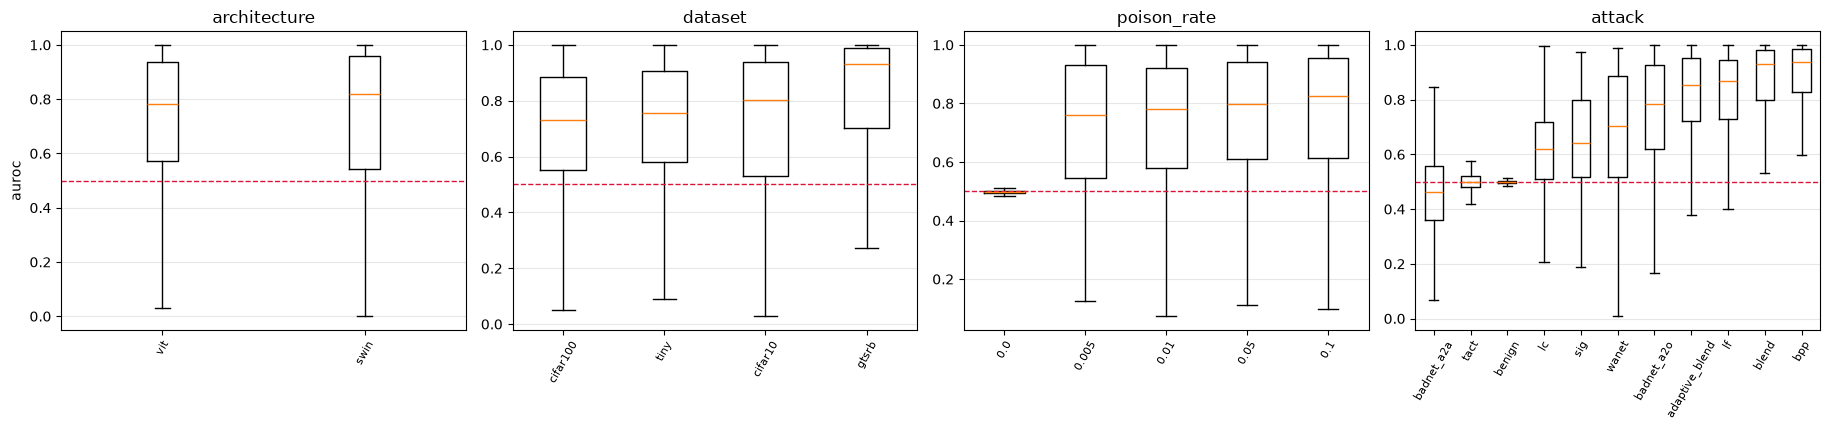

In [15]:
def plot_breakdowns(frame):
    columns = ["architecture", "dataset", "poison_rate", "attack"]
    figure, axes = plt.subplots(1, len(columns), figsize=(4.6 * len(columns), 4.4))
    for axis, column in zip(axes, columns):
        groups = frame.groupby(column)["auroc"]
        order = groups.median().sort_values().index
        axis.boxplot(
            [groups.get_group(key).to_numpy() for key in order],
            tick_labels=[str(key) for key in order],
            showfliers=False,
        )
        axis.axhline(0.5, ls="--", lw=1, c="crimson")
        axis.set_title(column)
        axis.tick_params(axis="x", rotation=60, labelsize=8)
        axis.grid(alpha=0.3, axis="y")
    axes[0].set_ylabel("auroc")
    figure.tight_layout()
    return figure


plot_breakdowns(frame)
plt.show()

## The oracle against the deployable rule

This is the single most important honesty point in the file. `adaptive` is what a
defender gets: the smallest rate whose clean validation shift ratio reaches the
paper's target, chosen without ever touching a poison label. `oracle` is the rate
with the best AUROC, chosen with full knowledge of the answer.

Both are paired on the same cell, so the difference is purely the cost of not
knowing the right rate in advance.

In [16]:
keys = ["folder", "placement"]
deployable = frame[frame["rule"] == "adaptive"].set_index(keys)
hindsight = frame[frame["rule"] == "oracle"].set_index(keys)
paired = deployable.join(
    hindsight[["auroc", "tpr", "fpr", "rate"]], rsuffix="_oracle", how="inner"
)
paired["d_auroc"] = paired["auroc_oracle"] - paired["auroc"]
paired["d_tpr"] = paired["tpr_oracle"] - paired["tpr"]

print(f"cells where both rules exist: {len(paired)}")
gap = pd.DataFrame(
    {
        "deployable": [
            paired["auroc"].mean(),
            paired["tpr"].mean(),
            paired["fpr"].mean(),
        ],
        "oracle": [
            paired["auroc_oracle"].mean(),
            paired["tpr_oracle"].mean(),
            paired["fpr_oracle"].mean(),
        ],
    },
    index=["mean auroc", "mean tpr", "mean fpr"],
)
gap["gap"] = gap["oracle"] - gap["deployable"]
gap.round(4)

cells where both rules exist: 4843


,deployable,oracle,gap
mean auroc,0.7667,0.8285,0.0618
mean tpr,0.6424,0.7453,0.1029
mean fpr,0.2431,0.2430,-0.0001


In [17]:
print(
    f"cells where the oracle picked the same rate as the deployable rule : "
    f"{int((paired['rate'] == paired['rate_oracle']).sum())} / {len(paired)}"
)
print(
    f"cells where oracle auroc is not worse                              : "
    f"{int((paired['auroc_oracle'] >= paired['auroc']).sum())} / {len(paired)}"
)
print(
    f"cells the deployable rule inverts and the oracle does not          : "
    f"{int(((paired['auroc'] < 0.5) & (paired['auroc_oracle'] >= 0.5)).sum())}"
)
print()
print("gap by dataset and poison rate")
paired.groupby(["dataset", "poison_rate"])[["d_auroc", "d_tpr"]].agg(
    ["mean", "size"]
).round(3)

cells where the oracle picked the same rate as the deployable rule : 1528 / 4843
cells where oracle auroc is not worse                              : 4843 / 4843
cells the deployable rule inverts and the oracle does not          : 469

gap by dataset and poison rate


d_auroc       d_tpr     
                        mean size   mean size
dataset  poison_rate                         
cifar10  0.000         0.005   50  0.018   50
         0.005         0.046   74  0.076   74
         0.010         0.065  289  0.100  289
         0.050         0.043  366  0.079  366
         0.100         0.063  506  0.117  506
cifar100 0.000         0.006   45  0.001   45
         0.005         0.040   46  0.072   46
         0.010         0.055  382  0.095  382
         0.050         0.064  460  0.117  460
         0.100         0.072  442  0.114  442
gtsrb    0.000         0.005   45  0.002   45
         0.010         0.088  195  0.120  195
         0.050         0.080  337  0.120  337
         0.100         0.034  334  0.037  334
tiny     0.000         0.002   48 -0.001   48
         0.010         0.067  298  0.131  298
         0.050         0.075  471  0.122  471
         0.100         0.074  455  0.128  455

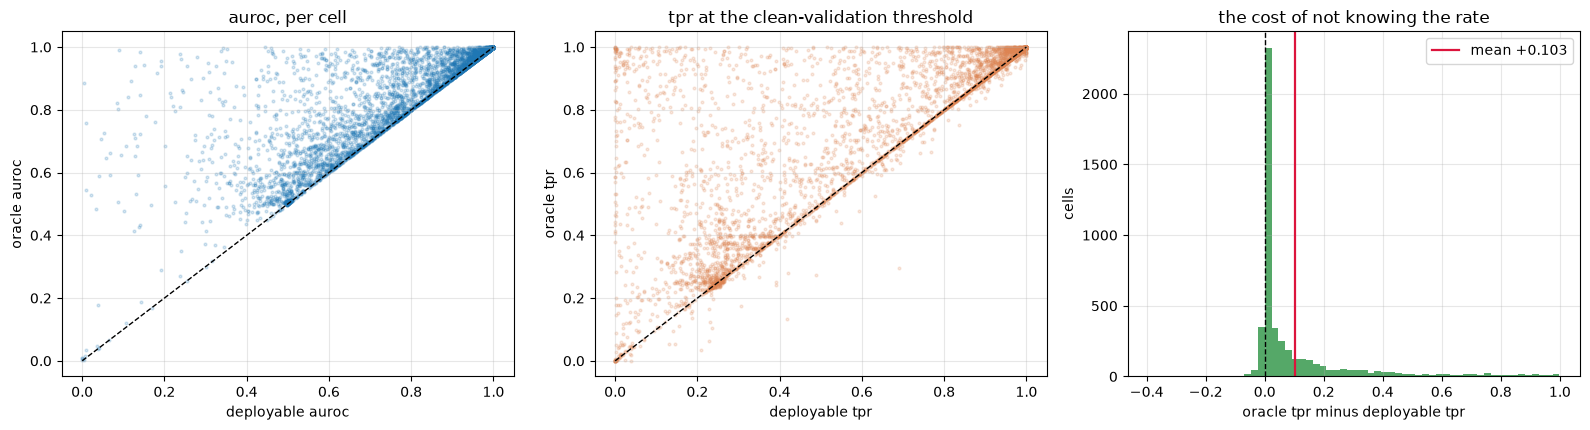

In [18]:
def plot_oracle_gap(paired):
    figure, axes = plt.subplots(1, 3, figsize=(16, 4.4))

    axes[0].scatter(paired["auroc"], paired["auroc_oracle"], s=4, alpha=0.18)
    axes[0].plot([0, 1], [0, 1], ls="--", lw=1, c="black")
    axes[0].set_xlabel("deployable auroc")
    axes[0].set_ylabel("oracle auroc")
    axes[0].set_title("auroc, per cell")
    axes[0].grid(alpha=0.3)

    axes[1].scatter(
        paired["tpr"], paired["tpr_oracle"], s=4, alpha=0.18, color="#DD8452"
    )
    axes[1].plot([0, 1], [0, 1], ls="--", lw=1, c="black")
    axes[1].set_xlabel("deployable tpr")
    axes[1].set_ylabel("oracle tpr")
    axes[1].set_title("tpr at the clean-validation threshold")
    axes[1].grid(alpha=0.3)

    axes[2].hist(paired["d_tpr"], bins=60, color="#55A868")
    axes[2].axvline(0, ls="--", lw=1, c="black")
    axes[2].axvline(
        paired["d_tpr"].mean(),
        lw=1.6,
        c="crimson",
        label=f"mean {paired['d_tpr'].mean():+.3f}",
    )
    axes[2].set_xlabel("oracle tpr minus deployable tpr")
    axes[2].set_ylabel("cells")
    axes[2].set_title("the cost of not knowing the rate")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    figure.tight_layout()
    return figure


plot_oracle_gap(paired)
plt.show()

The oracle is never worse, by construction, so the interesting quantities are the
size of the gap and how often the 2 rules disagree at all. They pick the same rate
on well under half the cells, and where they differ the hindsight rate buys about
0.06 AUROC and about 0.10 TPR.

The number that should shape how these tables are read is the count of cells the
deployable rule inverts and the oracle does not. Those are cells where a defender
running the published rate rule gets a detector that runs backwards, and where a
table reporting only the oracle column would show a working one.

## Inversions

An inversion is AUROC below 0.5: backdoored inputs are scored as *more* suspicious
in the wrong direction, so the low tail of the statistic is enriched for clean
samples. The project's convention is to print these as the failures they are rather
than flip them, because choosing which tail to flag needs the poison labels the
detector exists to predict (H15).

In [19]:
frame["inverted"] = frame["auroc"] < 0.5
print(
    f"inverted rows: {int(frame['inverted'].sum())} of {len(frame)} "
    f"({frame['inverted'].mean():.1%})"
)
print()
print("by rule")
print(frame.groupby("rule")["inverted"].agg(["sum", "size", "mean"]).round(3))

inverted rows: 5237 of 30378 (17.2%)

by rule
                   sum  size   mean
rule                               
adaptive           559  4843  0.115
matched_sigma0.2  1474  5107  0.289
matched_sigma0.4  1264  5107  0.248
matched_sigma0.6  1022  5107  0.200
matched_sigma0.8   743  5107  0.145
oracle             175  5107  0.034


The rate rule alone moves the inversion rate by a factor of about 9, from the
hindsight rate to the weakest matched target. That is the H9 warning as a single
table: a placement measured outside its own operating range looks broken.

In [20]:
print("by attack")
print(
    frame.groupby("attack")["inverted"]
    .agg(["sum", "size", "mean"])
    .sort_values("mean", ascending=False)
    .round(3)
)
print()
print("by operator")
print(
    frame.groupby("operator")["inverted"]
    .agg(["sum", "size", "mean"])
    .sort_values("mean", ascending=False)
    .round(3)
)

by attack
                 sum  size   mean
attack                           
badnet_a2a      1743  2847  0.612
benign           689  1173  0.587
tact             197   378  0.521
sig              213   925  0.230
wanet            650  2853  0.228
lc               474  2104  0.225
badnet_a2o       556  4309  0.129
blend            263  4394  0.060
adaptive_blend   178  3415  0.052
lf               150  3727  0.040
bpp              124  4253  0.029

by operator
               sum  size   mean
operator                       
gain_scale     595  2485  0.239
dropout       1614  8608  0.188
token_mask    1140  6378  0.179
channel_mask   970  6233  0.156
gaussian       604  4135  0.146
scale_up        66   499  0.132
droppath       193  1530  0.126
head_mask       55   510  0.108


In [21]:
position_inversions = frame.groupby("position")["inverted"].agg(["sum", "size", "mean"])
position_inversions = position_inversions[position_inversions["size"] >= 300]
print("by position, positions with at least 300 rows")
position_inversions.sort_values("mean", ascending=False).round(3)

by position, positions with at least 300 rows


,sum,size,mean
position,,,
final_norm_out,255,505,0.505
before_attention_norm,1149,4759,0.241
after_embedding,347,1626,0.213
before_mlp_norm,270,1374,0.197
mlp_norm_out,255,1374,0.186
before_mlp,319,2030,0.157
pre_residual,729,4725,0.154
after_attention_residual,240,1578,0.152
before_mlp_residual,378,2592,0.146


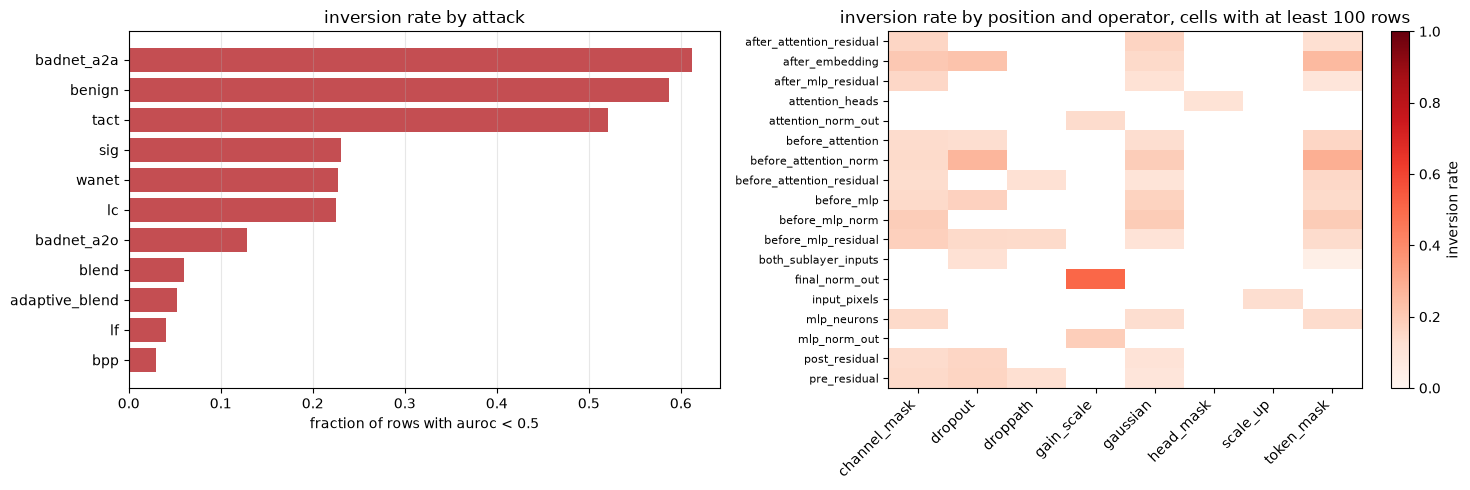

In [22]:
def plot_inversions(frame):
    figure, axes = plt.subplots(1, 2, figsize=(15, 5))

    attacks = frame.groupby("attack")["inverted"].mean().sort_values()
    axes[0].barh(attacks.index, attacks.to_numpy(), color="#C44E52")
    axes[0].set_xlabel("fraction of rows with auroc < 0.5")
    axes[0].set_title("inversion rate by attack")
    axes[0].grid(alpha=0.3, axis="x")

    table = frame.pivot_table(
        index="position", columns="operator", values="inverted", aggfunc="mean"
    ).dropna(how="all")
    counts = frame.pivot_table(
        index="position", columns="operator", values="inverted", aggfunc="size"
    )
    table = table.where(counts >= 100)
    table = table.dropna(how="all").dropna(axis=1, how="all")
    image = axes[1].imshow(table.to_numpy(), cmap="Reds", vmin=0, vmax=1, aspect="auto")
    axes[1].set_xticks(range(table.shape[1]))
    axes[1].set_xticklabels(table.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(table.shape[0]))
    axes[1].set_yticklabels(table.index, fontsize=8)
    axes[1].set_title(
        "inversion rate by position and operator, cells with at least 100 rows"
    )
    figure.colorbar(image, ax=axes[1], label="inversion rate")
    figure.tight_layout()
    return figure


plot_inversions(frame)
plt.show()

`badnet_a2a`, `benign` and `tact` head that column and none of the three is a
detection failure. All-to-all has no single target class for the perturbed
prediction to collapse onto, so PSBD's premise does not hold and the signal appears
with the sign reversed (H5). A benign model has no backdoor, so its AUROC should be
0.5 and scatters either side of it. `tact` never implanted at all, with a peak ASR
of 0.121 in this file.

Once those three are set aside the ordering is a statement about triggers. The
residual inversions concentrate on `wanet`, `lc` and `sig`, which are the attacks
that implant weakly, and on positions that read a normalized tensor.

In [23]:
real = frame[(frame["asr"] >= 0.5) & (~frame["attack"].isin(["benign", "badnet_a2a"]))]
print(
    f"inversions among implanted, single-target attacks: "
    f"{int((real['auroc'] < 0.5).sum())} of {len(real)} ({(real['auroc'] < 0.5).mean():.1%})"
)
worst = (
    real.assign(inverted=real["auroc"] < 0.5)
    .groupby(["operator", "position"])["inverted"]
    .agg(["sum", "size", "mean"])
)
worst = worst[worst["size"] >= 100].sort_values("mean", ascending=False)
print()
print("the 10 placements that invert most often")
worst.head(10).round(3)

inversions among implanted, single-target attacks: 2256 of 25100 (9.0%)

the 10 placements that invert most often


sum  size   mean
operator     position                               
gain_scale   final_norm_out         250   425  0.588
token_mask   before_attention_norm  232  1014  0.229
             after_embedding         98   510  0.192
dropout      before_attention_norm  289  1609  0.180
channel_mask after_embedding         61   432  0.141
gaussian     before_attention_norm   55   426  0.129
             before_mlp_norm         28   222  0.126
dropout      both_sublayer_inputs    34   288  0.118
gain_scale   mlp_norm_out           110  1014  0.108
             attention_norm_out      53   510  0.104

## What this file can and cannot answer

It can answer anything about rate selection, because all 6 rules are stored side by
side on the same cells. It can answer anything about the shape of the AUROC
distribution and where the failures are.

It cannot answer 2 things, and both are properties of how it was built rather than
of the experiment:

1. **It carries 1 score kind.** `cli/analyze.py` computes detection under both
   absolute PSU and fractional PSU, but only the absolute form is propagated into
   the rate-selection blocks that `scripts/detection_summary.py` reads. The
   fractional numbers live per rate inside `psbd_metrics.json` and never reach the
   CSV. The results report states that its numbers are fractional PSU.
2. **It carries 1 sigma matching rule**, the nearest rate. The other rule, the
   smallest rate that reaches the target, produces materially different answers on
   a coarse rate grid.

Notebook 09 takes both of those apart, because together they decide whether the
project's headline number reproduces.

In [24]:
with open("results/vit_cifar100_badnet_a2o_0_01/psbd_metrics.json") as handle:
    block = json.load(handle)["placements"]["before_attention_norm_token_mask"]

matched = block["matched_shift"]["sigma0.6"]
at_rate = next(row for row in block["rates"] if row["rate"] == matched["rate"])
print(f"matched_sigma0.6 auroc recorded in the CSV      : {matched['auroc']:.6f}")
print(
    f"same rate, absolute PSU   (detection)           : {at_rate['detection']['q0.25']['auroc']:.6f}"
)
print(
    f"same rate, fractional PSU (detection_psu_ratio) : "
    f"{at_rate['detection_psu_ratio']['q0.25']['auroc']:.6f}"
)

matched_sigma0.6 auroc recorded in the CSV      : 0.958136
same rate, absolute PSU   (detection)           : 0.958136
same rate, fractional PSU (detection_psu_ratio) : 0.960473
